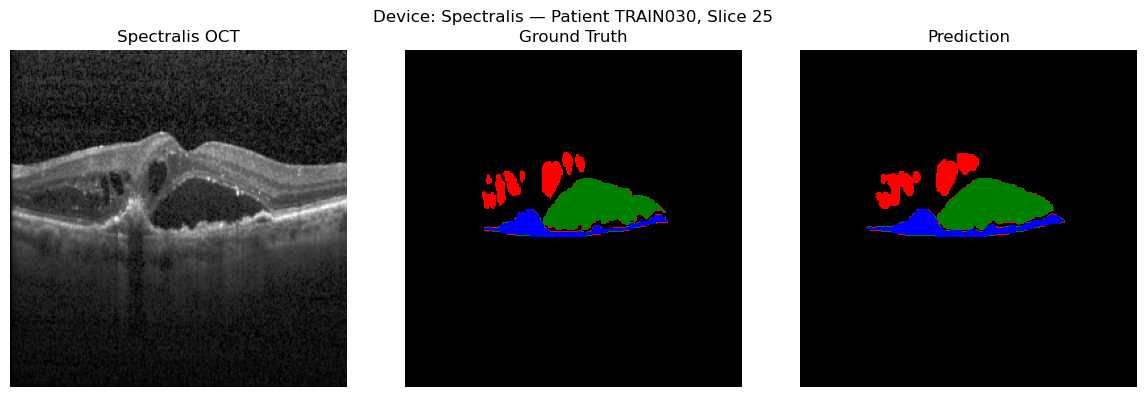

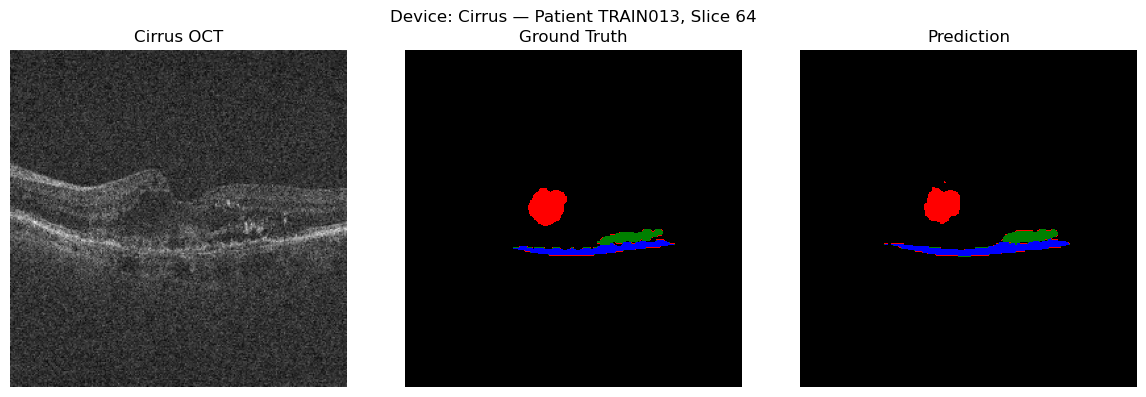

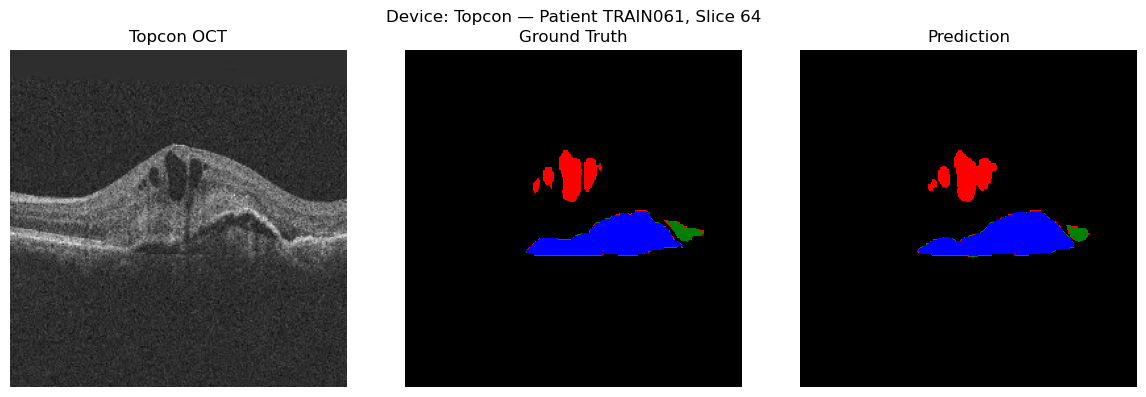

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from DataReader import DataReader
from losses    import Losses

# 1) Configuration
devices    = ['Spectralis','Cirrus','Topcon']
data_root  = 'RetouchData'
model_root = 'Spectralis_Cirrus_Topcon'
cmap       = ListedColormap(['black','red','green','blue'])

patient_map = {
    'Spectralis': 'TRAIN030',
    'Cirrus'   : 'TRAIN013',
    'Topcon'   : 'TRAIN061',
}

slice_map = {
    'Spectralis': 25,
    'Cirrus'   : 64,
    'Topcon'   : 64,
}

# 2) Helpers
data_reader = DataReader()
loss_funcs  = Losses()

def predict_mask(model, img_tensor):
    out      = model.predict(img_tensor[None], verbose=0)[0]
    conn32   = out[...,:32]
    prob_maps = []
    for cls in range(4):
        cm = conn32[..., cls*8:(cls+1)*8]
        pm = loss_funcs.bv_test_new(tf.expand_dims(cm, 0)).numpy()
        prob_maps.append(pm)
    stack = np.stack(prob_maps, axis=-1)
    return np.argmax(stack, axis=-1)

def plot_for_device(ds, slice_idx):
    # look up patient
    patient = patient_map[ds]
    # load model once (pooled final model)
    model = tf.keras.models.load_model(
        f"{model_root}/final_model.hdf5",
        custom_objects={'training_loss': loss_funcs.training_loss,
                        'dice':            loss_funcs.dice}
    )

    # load image & ground truth
    img_path = f"{data_root}/{ds}/retouch_data/{patient}/{patient}_oct_{slice_idx:03d}.jpg"
    img, gt_mask = data_reader.load_image(tf.constant(img_path))
    gt_mask = gt_mask.numpy()[...,0].astype(int)

    # predict
    pred_mask = predict_mask(model, img)

    # plot
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    axs[0].imshow(img[...,0],   cmap='gray');              axs[0].set_title(f"{ds} OCT");        axs[0].axis('off')
    axs[1].imshow(gt_mask,      cmap=cmap, vmin=0, vmax=3); axs[1].set_title("Ground Truth");    axs[1].axis('off')
    axs[2].imshow(pred_mask,    cmap=cmap, vmin=0, vmax=3); axs[2].set_title("Prediction");      axs[2].axis('off')

    plt.suptitle(f"Device: {ds} — Patient {patient}, Slice {slice_idx}")
    plt.tight_layout()
    plt.show()

plot_for_device('Spectralis', slice_map['Spectralis'])
plot_for_device('Cirrus',    slice_map['Cirrus'])
plot_for_device('Topcon',    slice_map['Topcon'])


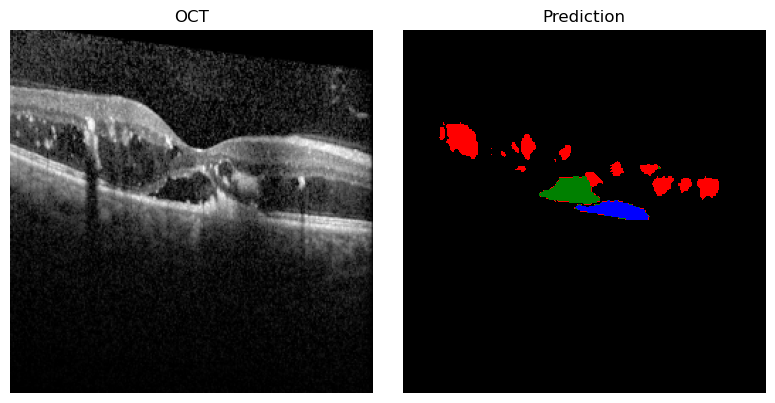

In [123]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from losses import Losses

# load model
model = tf.keras.models.load_model(
    "Spectralis_Cirrus_Topcon/final_model.hdf5",
    custom_objects={"training_loss": Losses().training_loss,
                    "dice":          Losses().dice}
)
loss_funcs = Losses()

# image processor
def load_oct_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [256,256])
    return tf.cast(img, tf.float32)/255.0

# patched predict_mask
def predict_mask(model, img_tensor):
    out    = model.predict(img_tensor[None], verbose=0)[0]
    conn32 = out[..., :32]
    prob_maps = []
    for cls in range(4):
        cm = conn32[..., cls*8:(cls+1)*8]
        bv = loss_funcs.bv_test_new(tf.expand_dims(cm,0)).numpy()  # (256,256)
        pm = bv                                                      # keep full 2D
        prob_maps.append(pm)
    stack = np.stack(prob_maps, axis=-1)    # (256,256,4)
    return np.argmax(stack, axis=-1)        # (256,256)

# run
# img = load_oct_image("RetouchData/Spectralis/Oct-24BF3B40.png").numpy() # Healthy Slice?
# img = load_oct_image("RetouchData/Spectralis/Oct-2E2DAD70.png").numpy() # IRF
img = load_oct_image("RetouchData/Spectralis/Oct-FC2E6C10.png").numpy() # 3 Fluid
# img = load_oct_image("RetouchData/Spectralis/Oct-FC98D450.png").numpy() # Failed on SRF?
# img = load_oct_image("RetouchData/Spectralis/Oct-B98B3BA0.png").numpy() # It sees a little of SRF?
# img = load_oct_image("RetouchData/Spectralis/Oct-28EA8400.png").numpy() # A weird one
# img = load_oct_image("RetouchData/Spectralis/288F6400.jpg").numpy() # A weird one + 1? [104653942] IRVIN, EVA 11/4/2024 2:11:03 PM
# img = load_oct_image("RetouchData/Spectralis/Oct-624805A0.png").numpy() # Another weird one


pred = predict_mask(model, img)

# plot
cmap = ListedColormap(['black','red','green','blue'])
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,4))
ax1.imshow(img[...,0], cmap='gray'); ax1.axis('off'); ax1.set_title("OCT")
ax2.imshow(pred, cmap=cmap, vmin=0, vmax=3); ax2.axis('off'); ax2.set_title("Prediction")
plt.tight_layout()
plt.show()


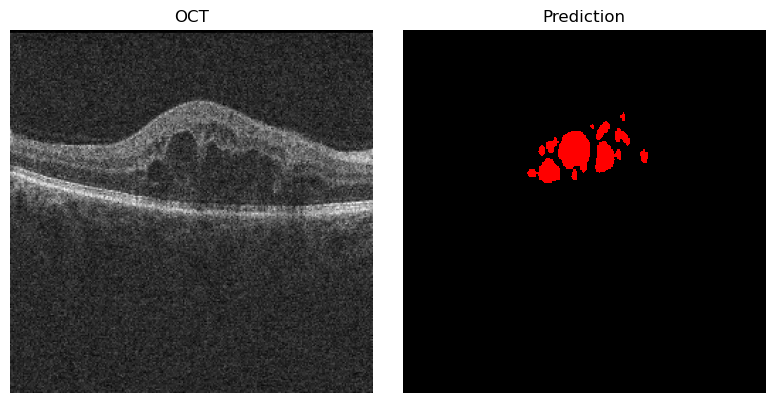

In [124]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from losses import Losses

# load model
model = tf.keras.models.load_model(
    "Spectralis_Cirrus_Topcon/final_model.hdf5",
    custom_objects={"training_loss": Losses().training_loss,
                    "dice":          Losses().dice}
)
loss_funcs = Losses()

# image processor
def load_oct_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [256,256])
    return tf.cast(img, tf.float32)/255.0

# patched predict_mask
def predict_mask(model, img_tensor):
    out    = model.predict(img_tensor[None], verbose=0)[0]
    conn32 = out[..., :32]
    prob_maps = []
    for cls in range(4):
        cm = conn32[..., cls*8:(cls+1)*8]
        bv = loss_funcs.bv_test_new(tf.expand_dims(cm,0)).numpy()  # (256,256)
        pm = bv                                                      # keep full 2D
        prob_maps.append(pm)
    stack = np.stack(prob_maps, axis=-1)    # (256,256,4)
    return np.argmax(stack, axis=-1)        # (256,256)

# run
# img = load_oct_image("RetouchData/Cirrus/Cube-1.2.276.0.75.2.2.42.50125197688.20220316154046221.5712517590_026.png").numpy() # IRF
img = load_oct_image("RetouchData/Cirrus/Cube-1.2.276.0.75.2.2.42.896740617523.20181219141839542.369651319_050.png").numpy() # IRF
# img = load_oct_image("RetouchData/Cirrus/Cube-1.2.276.0.75.2.2.42.896740617523.20181219141839542.369651319_062.png").numpy() # IRF
# img = load_oct_image("RetouchData/Cirrus/Cube-1.2.276.0.75.2.2.42.50125197688.20191120124821685.4344336080_064.png").numpy() # A little PED!
# img = load_oct_image("RetouchData/Cirrus/Cube-1.2.276.0.75.2.2.42.50125197688.20210519150500555.1877238849_049.png").numpy() # Healthy?
# img = load_oct_image("RetouchData/Cirrus/Cube-1.2.276.0.75.2.2.42.50125197688.20190221084120036.3272829600_034.png").numpy() # Healthy?
# img = load_oct_image("RetouchData/Cirrus/Cube-1.2.276.0.75.2.2.42.50125197688.20210811135346875.4632450710_070.png").numpy() # Weird but have SRF


pred = predict_mask(model, img)

# plot
cmap = ListedColormap(['black','red','green','blue'])
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,4))
ax1.imshow(img[...,0], cmap='gray'); ax1.axis('off'); ax1.set_title("OCT")
ax2.imshow(pred, cmap=cmap, vmin=0, vmax=3); ax2.axis('off'); ax2.set_title("Prediction")
plt.tight_layout()
plt.show()
